# 06. Affine transformations


## Learning goals

After working through this notebook, you should be able to:

- explain what an affine pullback does to a sampled two-dimensional function,
- distinguish periodic and open boundary behavior for the same affine map,
- build and apply a multivariate affine pullback operator in `Tensor4all.jl`,
- compare transformed QTT values against dense analytic references,
- read bond-dimension profiles for the source state, transformed states, and affine MPOs.


In [12]:
using Tensor4all
using CairoMakie

const QG = Tensor4all.QuanticsGrids
const QTCI = Tensor4all.QuanticsTCI
const QT = Tensor4all.QuanticsTransform
const STT = Tensor4all.SimpleTT
const TN = Tensor4all.TensorNetworks;

## Before you run this notebook


Run the repository setup once before executing the code cells:

```bash
julia --project=. -e 'using Pkg; Pkg.instantiate(); Pkg.build("Tensor4all"); Pkg.precompile()'
```

Then open the notebook with the same Julia version you used for setup. The notebooks in this repository were tested with Julia 1.12.


## Concept

We start from a source function $g(u, v)$ on a finite two-dimensional grid and build a new function by sampling $g$ at transformed coordinates.

In this notebook, the affine map is

$$
\begin{bmatrix} u \\ v \end{bmatrix}
=
\begin{bmatrix} 1 & 1 \\ 0 & 1 \end{bmatrix}
\begin{bmatrix} x \\ y \end{bmatrix}.
$$

So the transformed field is

$$
f(x, y) = g(x + y, y).
$$

This is a pullback: we keep the output coordinates $(x, y)$ fixed and look up the source function at transformed source coordinates $(u, v)$. In `Tensor4all.jl`, the affine pullback is represented as an MPO and applied directly to the QTT state.

We will study the same affine map with two different boundary conditions:

- **periodic:** values that leave the grid wrap around,
- **open:** values outside the grid are set to zero.


## Source field and fused quantics grid


The source function is

$$
g(u, v) = \sin\!\left(\frac{2\pi u}{N}\right)
+ \tfrac{1}{2}\cos\!\left(\frac{2\pi v}{N}\right)
+ \tfrac{1}{4}\sin\!\left(\frac{2\pi (u + 2v)}{N}\right).
$$

We use a fused two-dimensional quantics grid. Each site stores one bit from $x$ and one bit from $y$, so the physical site dimension is $4$ rather than $2$. The grid bounds are chosen so that the physical coordinates are the integer samples $0, 1, \dots, N-1$.


In [2]:
R = 6
npoints = 1 << R

value_type = Float64
tolerance = 1e-12
maxbonddim = 64
maxiter = 20

grid = QG.DiscretizedGrid(
    (:x, :y), (R, R);
    lower_bound=0.0,
    upper_bound=Float64(npoints),
    unfoldingscheme=:fused,
    includeendpoint=false,
)

x_coords = [QG.grididx_to_origcoord(grid, (i, 1))[1] for i in 1:npoints]
y_coords = [QG.grididx_to_origcoord(grid, (1, j))[2] for j in 1:npoints]

source_function(u, v, N) =
    sin(2π * u / N) + 0.5 * cos(2π * v / N) + 0.25 * sin(2π * (u + 2v) / N)

periodic_reference(x, y, N) = source_function(mod(x + y, N), y, N)
open_reference(x, y, N) = x + y >= N ? 0.0 : source_function(x + y, y, N)

source_exact = [source_function(x, y, npoints) for x in 0:npoints-1, y in 0:npoints-1]
field_limits = extrema(source_exact)

println("R = $R gives $npoints grid points in each direction.")
println("The fused grid uses site dimension 4 because each site carries one x-bit and one y-bit.")
println("Physical coordinates run from $(x_coords[1]) to $(x_coords[end]).")


R = 6 gives 64 grid points in each direction.
The fused grid uses site dimension 4 because each site carries one x-bit and one y-bit.
Physical coordinates run from 0.0 to 63.0.


In [3]:
source_qtt, _, _ = QTCI.quanticscrossinterpolate(
    value_type,
    (u, v) -> source_function(u, v, npoints),
    grid;
    tolerance=tolerance,
    maxbonddim=maxbonddim,
    maxiter=maxiter,
)

source_values = [real(source_qtt([i, j])) for i in 1:npoints, j in 1:npoints]
source_max_abs_error = maximum(abs.(source_exact .- source_values))

source_simple = STT.TensorTrain(source_qtt.tci)
source_sites = [Tensor4all.Index(4; tags=["xy", "bit=$i"]) for i in 1:length(source_simple)]
source_state = TN.TensorTrain(source_simple, source_sites)
source_bond_dims = TN.linkdims(source_state)

println("Source QTT built on the fused grid.")
println("Maximum absolute error on the full source grid: $source_max_abs_error")
println("Source-state bond dimensions: $source_bond_dims")


Source QTT built on the fused grid.
Maximum absolute error on the full source grid: 2.123301534595612e-15
Source-state bond dimensions: [2, 6, 6, 6, 4]


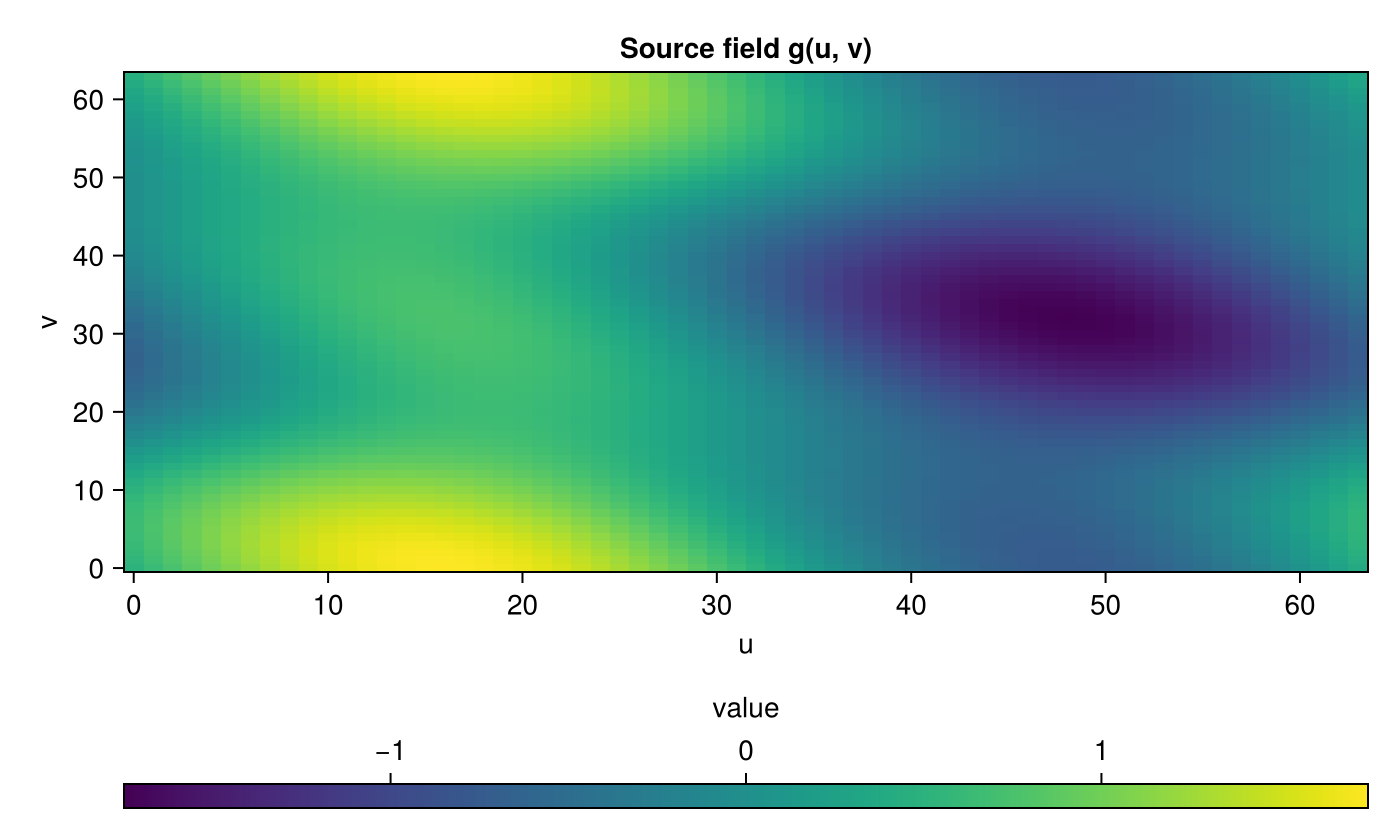

In [4]:
fig_source = Figure(size=(700, 420))
ax_source = Axis(
    fig_source[1, 1],
    xlabel="u",
    ylabel="v",
    title="Source field g(u, v)",
)
hm_source = heatmap!(
    ax_source,
    x_coords,
    y_coords,
    source_exact;
    colormap=:viridis,
    colorrange=field_limits,
    interpolate=false,
)
Colorbar(fig_source[2, 1], hm_source; vertical=false, label="value")
fig_source


## Periodic affine pullback


The matrix entries for the affine operator are passed in column-major order. So the vector

```julia
[1, 0, 1, 1]
```

represents the matrix

$$
\begin{bmatrix} 1 & 1 \\ 0 & 1 \end{bmatrix}.
$$

We bind the operator to the same fused site indices as the source state. `set_iospaces!` tells the operator on which site indices it should read input and on which site indices it should return output. Here both are the same `source_sites`, because the affine pullback maps one fused 2D state to another fused 2D state on the same output grid.

For periodic boundaries, the first transformed coordinate wraps modulo $N$.


In [5]:
a_num = [1, 0, 1, 1]
a_den = [1, 1, 1, 1]
b_num = [0, 0]
b_den = [1, 1]

periodic_operator = QT.affine_pullback_operator_multivar(
    R,
    a_num,
    a_den,
    b_num,
    b_den,
    2,
    2;
    bc=fill(:periodic, 2),
)

TN.set_iospaces!(periodic_operator, source_sites, source_sites)
periodic_state = TN.apply(periodic_operator, source_state)

periodic_state_bond_dims = TN.linkdims(periodic_state)
periodic_operator_bond_dims = TN.linkdims(periodic_operator.mpo)

println("Built the periodic affine pullback operator.")
println("Periodic transformed-state bond dimensions: $periodic_state_bond_dims")
println("Periodic affine MPO bond dimensions: $periodic_operator_bond_dims")


Built the periodic affine pullback operator.
Periodic transformed-state bond dimensions: [4, 12, 12, 12, 4]
Periodic affine MPO bond dimensions: [2, 2, 2, 2, 2]


In [6]:
periodic_qtt_values = zeros(Float64, npoints, npoints)
periodic_reference_values = zeros(Float64, npoints, npoints)

for x_index in 1:npoints, y_index in 1:npoints
    site_vals = QG.grididx_to_quantics(grid, (x_index, y_index))
    periodic_qtt_values[x_index, y_index] = real(TN.evaluate(periodic_state, source_sites, site_vals))
    periodic_reference_values[x_index, y_index] = periodic_reference(x_index - 1, y_index - 1, npoints)
end

periodic_abs_error = abs.(periodic_qtt_values .- periodic_reference_values)
periodic_max_abs_error = maximum(periodic_abs_error)

println("Maximum absolute error for the periodic pullback: $periodic_max_abs_error")


Maximum absolute error for the periodic pullback: 5.551115123125783e-15


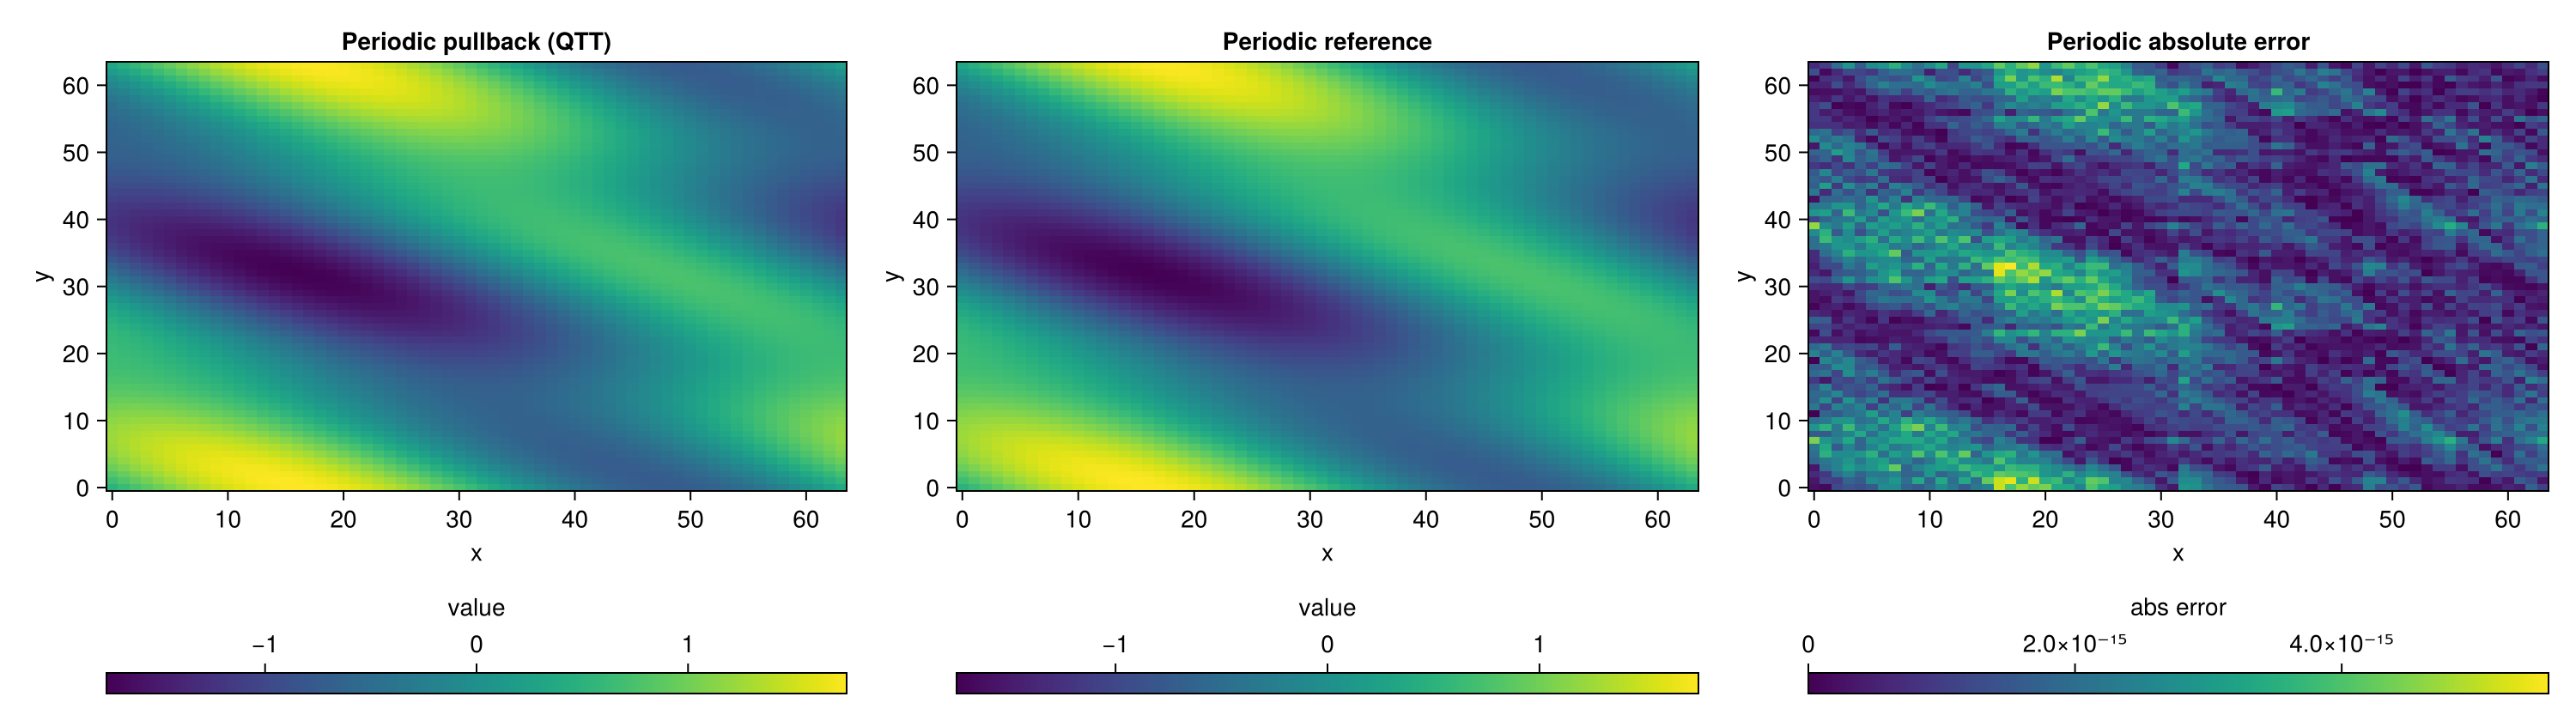

In [7]:
fig_periodic = Figure(size=(1500, 420))

ax_p1 = Axis(fig_periodic[1, 1], xlabel="x", ylabel="y", title="Periodic pullback (QTT)")
hm_p1 = heatmap!(
    ax_p1,
    x_coords,
    y_coords,
    periodic_qtt_values;
    colormap=:viridis,
    colorrange=field_limits,
    interpolate=false,
)
Colorbar(fig_periodic[2, 1], hm_p1; vertical=false, label="value")

ax_p2 = Axis(fig_periodic[1, 2], xlabel="x", ylabel="y", title="Periodic reference")
hm_p2 = heatmap!(
    ax_p2,
    x_coords,
    y_coords,
    periodic_reference_values;
    colormap=:viridis,
    colorrange=field_limits,
    interpolate=false,
)
Colorbar(fig_periodic[2, 2], hm_p2; vertical=false, label="value")

ax_p3 = Axis(fig_periodic[1, 3], xlabel="x", ylabel="y", title="Periodic absolute error")
hm_p3 = heatmap!(
    ax_p3,
    x_coords,
    y_coords,
    periodic_abs_error;
    colormap=:viridis,
    interpolate=false,
)
Colorbar(fig_periodic[2, 3], hm_p3; vertical=false, label="abs error")

fig_periodic


The periodic result wraps the lookup coordinate $u = x + y$ back into the finite grid. So the transformed field is a sheared version of the source, but without any loss of mass at the boundary.


## Open boundary variation


Now we keep the same affine map and only change the boundary handling. For open boundaries, any lookup point with $x + y \geq N$ lies outside the source grid and is set to zero. This creates a triangular zero region in the transformed field.


In [8]:
open_operator = QT.affine_pullback_operator_multivar(
    R,
    a_num,
    a_den,
    b_num,
    b_den,
    2,
    2;
    bc=fill(:open, 2),
)

TN.set_iospaces!(open_operator, source_sites, source_sites)
open_state = TN.apply(open_operator, source_state)

open_state_bond_dims = TN.linkdims(open_state)
open_operator_bond_dims = TN.linkdims(open_operator.mpo)

println("Built the open-boundary affine pullback operator.")
println("Open transformed-state bond dimensions: $open_state_bond_dims")
println("Open affine MPO bond dimensions: $open_operator_bond_dims")


Built the open-boundary affine pullback operator.
Open transformed-state bond dimensions: [4, 12, 12, 12, 4]
Open affine MPO bond dimensions: [2, 2, 2, 2, 2]


In [9]:
open_qtt_values = zeros(Float64, npoints, npoints)
open_reference_values = zeros(Float64, npoints, npoints)

for x_index in 1:npoints, y_index in 1:npoints
    site_vals = QG.grididx_to_quantics(grid, (x_index, y_index))
    open_qtt_values[x_index, y_index] = real(TN.evaluate(open_state, source_sites, site_vals))
    open_reference_values[x_index, y_index] = open_reference(x_index - 1, y_index - 1, npoints)
end

open_abs_error = abs.(open_qtt_values .- open_reference_values)
open_max_abs_error = maximum(open_abs_error)

println("Maximum absolute error for the open pullback: $open_max_abs_error")


Maximum absolute error for the open pullback: 5.551115123125783e-15


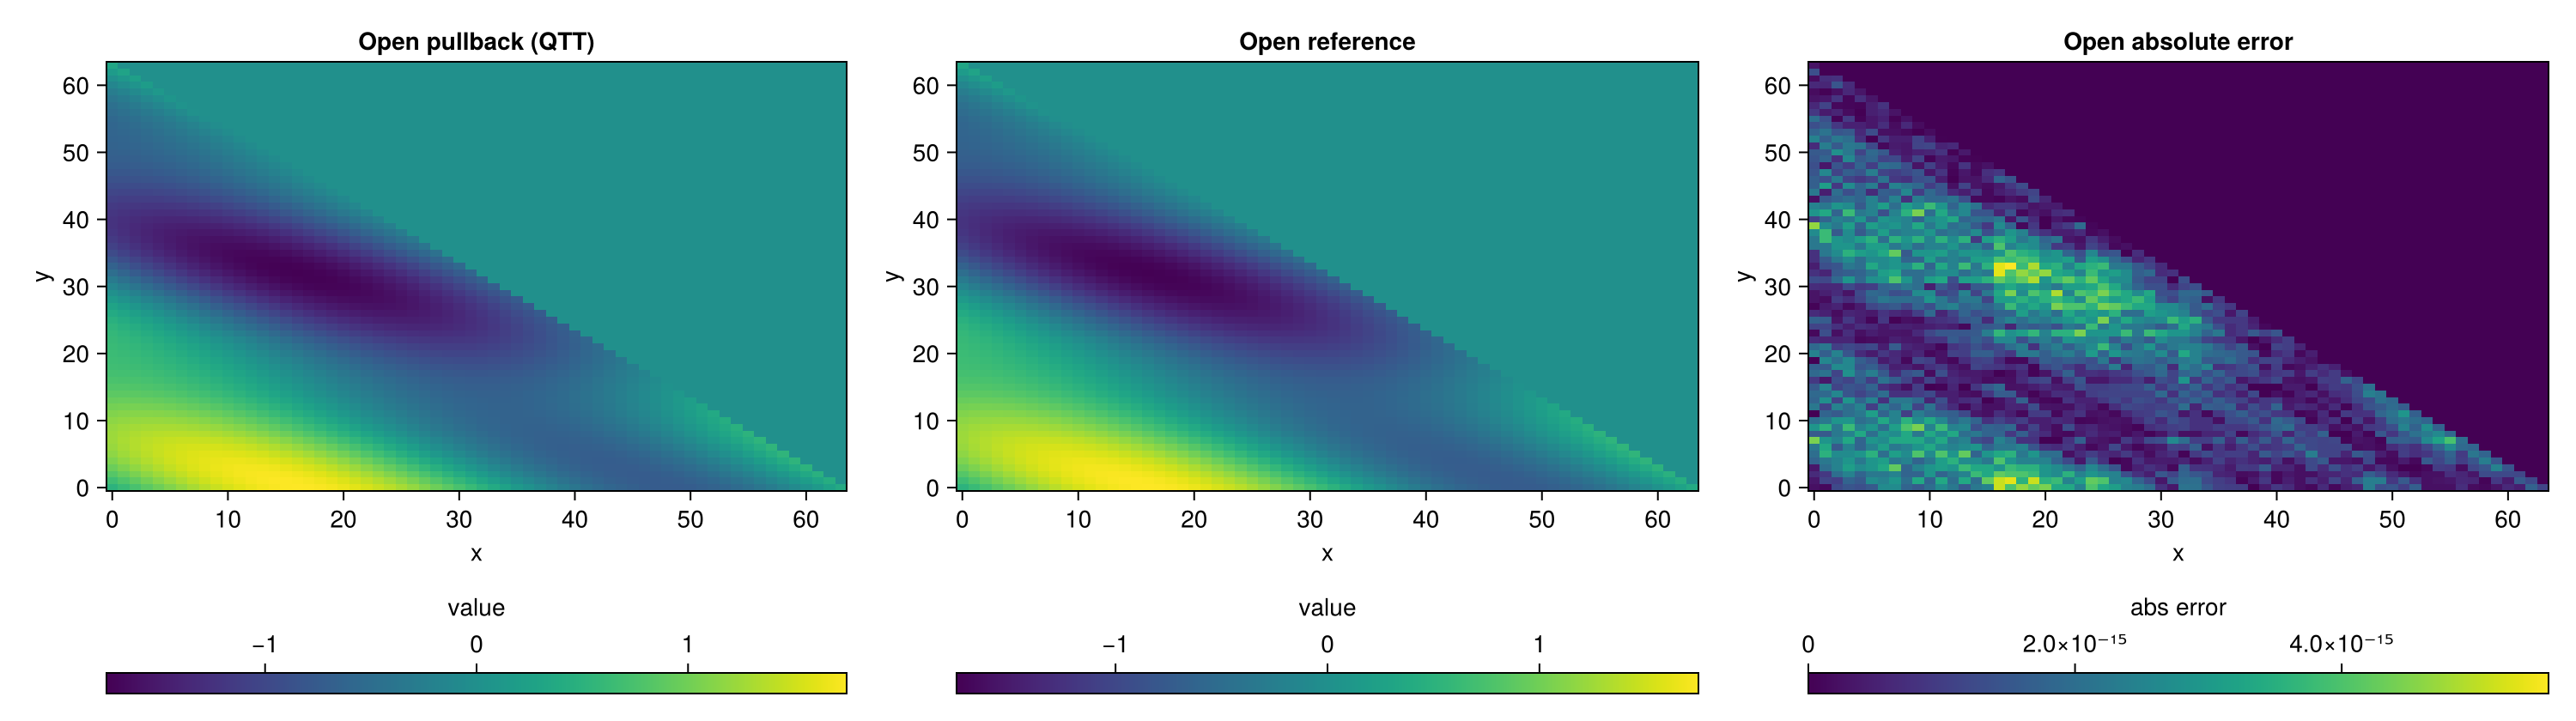

In [10]:
fig_open = Figure(size=(1500, 420))

ax_o1 = Axis(fig_open[1, 1], xlabel="x", ylabel="y", title="Open pullback (QTT)")
hm_o1 = heatmap!(
    ax_o1,
    x_coords,
    y_coords,
    open_qtt_values;
    colormap=:viridis,
    colorrange=field_limits,
    interpolate=false,
)
Colorbar(fig_open[2, 1], hm_o1; vertical=false, label="value")

ax_o2 = Axis(fig_open[1, 2], xlabel="x", ylabel="y", title="Open reference")
hm_o2 = heatmap!(
    ax_o2,
    x_coords,
    y_coords,
    open_reference_values;
    colormap=:viridis,
    colorrange=field_limits,
    interpolate=false,
)
Colorbar(fig_open[2, 2], hm_o2; vertical=false, label="value")

ax_o3 = Axis(fig_open[1, 3], xlabel="x", ylabel="y", title="Open absolute error")
hm_o3 = heatmap!(
    ax_o3,
    x_coords,
    y_coords,
    open_abs_error;
    colormap=:viridis,
    interpolate=false,
)
Colorbar(fig_open[2, 3], hm_o3; vertical=false, label="abs error")

fig_open


## Bond dimensions of states and operators


The transformed states and the affine MPOs have their own bond-dimension profiles. Because the fused layout uses site dimension $4$, we compare them against a simple worst-case envelope with base $4$. This is only a rough ceiling, but it helps us see how far the observed ranks stay below a generic unstructured case.


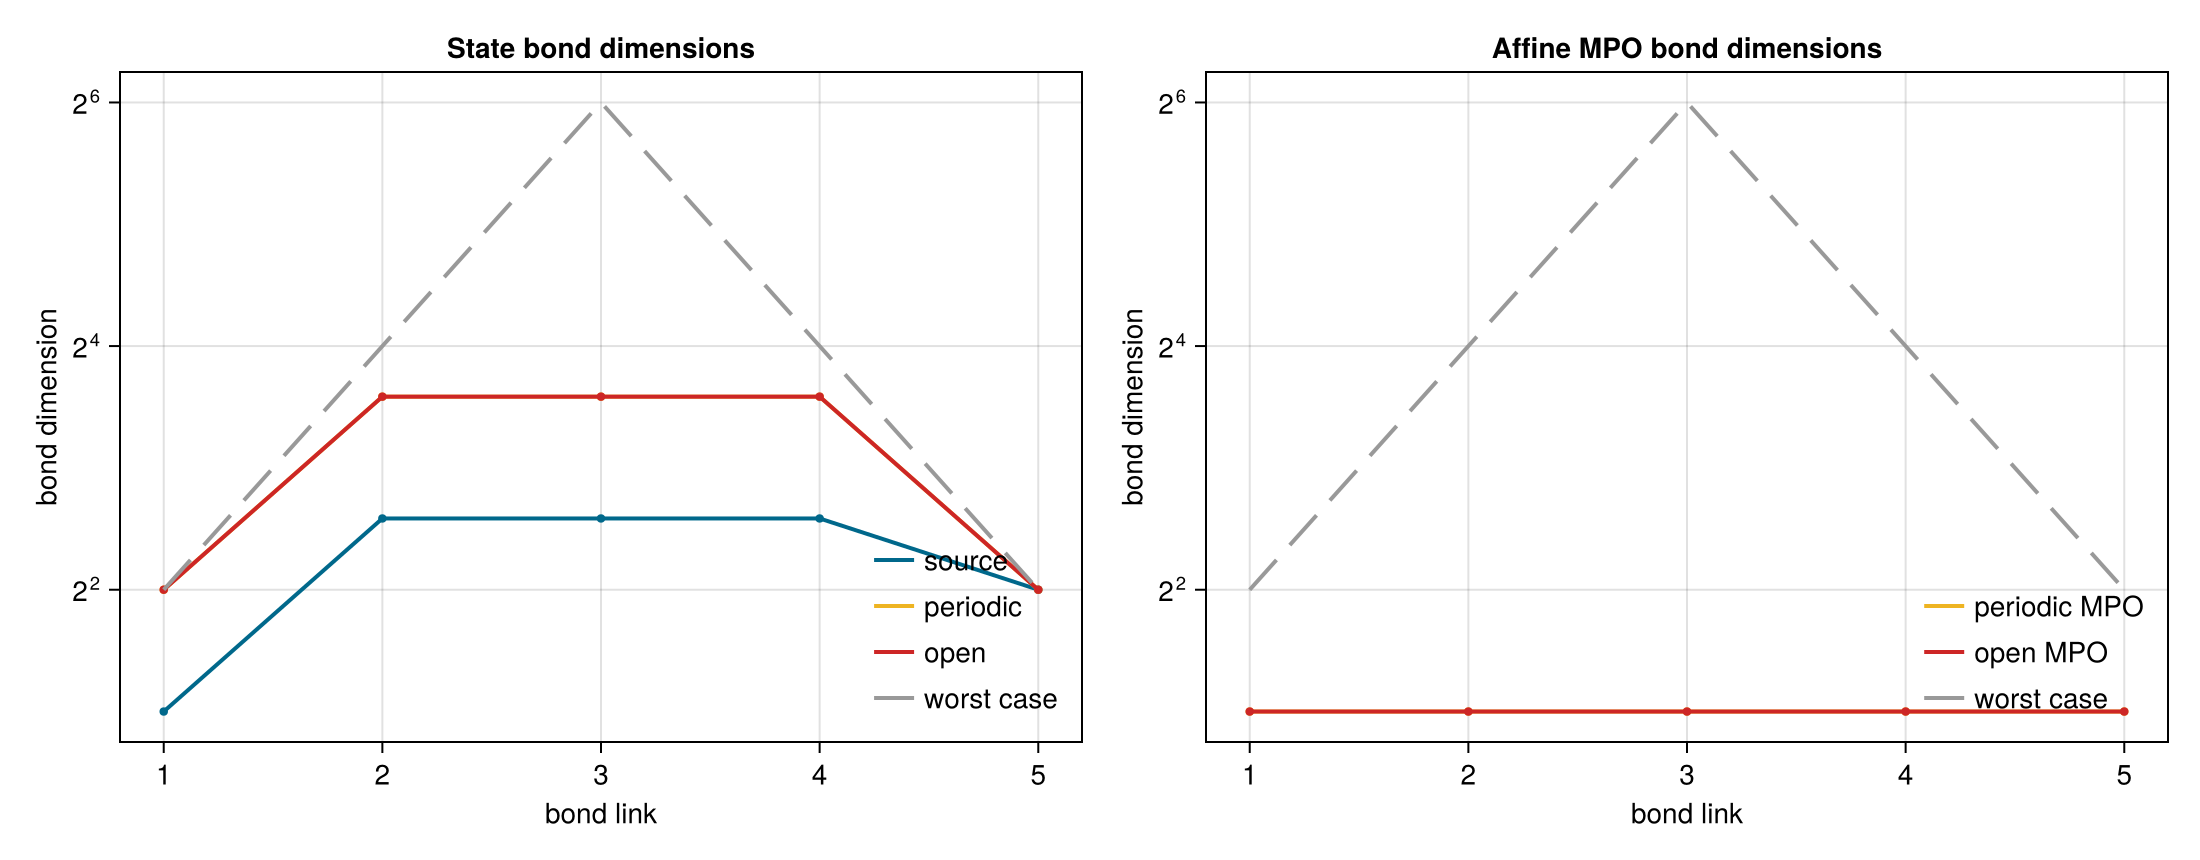

In [11]:
worst_case_bond_dims(num_bonds; base=4) =
    [base^min(k, num_bonds + 1 - k) for k in 1:num_bonds]

state_worst_case = worst_case_bond_dims(max(length(source_bond_dims), length(periodic_state_bond_dims), length(open_state_bond_dims)); base=4)
operator_worst_case = worst_case_bond_dims(max(length(periodic_operator_bond_dims), length(open_operator_bond_dims)); base=4)

fig_bonds = Figure(size=(1100, 430))

ax_b1 = Axis(
    fig_bonds[1, 1],
    xlabel="bond link",
    ylabel="bond dimension",
    title="State bond dimensions",
    yscale=log2,
)

source_idx = 1:length(source_bond_dims)
lines!(ax_b1, source_idx, source_bond_dims; color=:deepskyblue4, linewidth=2, label="source")
scatter!(ax_b1, source_idx, source_bond_dims; color=:deepskyblue4, markersize=6)

periodic_idx = 1:length(periodic_state_bond_dims)
lines!(ax_b1, periodic_idx, periodic_state_bond_dims; color=:goldenrod2, linewidth=2, label="periodic")
scatter!(ax_b1, periodic_idx, periodic_state_bond_dims; color=:goldenrod2, markersize=6)

open_idx = 1:length(open_state_bond_dims)
lines!(ax_b1, open_idx, open_state_bond_dims; color=:firebrick3, linewidth=2, label="open")
scatter!(ax_b1, open_idx, open_state_bond_dims; color=:firebrick3, markersize=6)

wc_state_idx = 1:length(state_worst_case)
lines!(ax_b1, wc_state_idx, state_worst_case;
    color=:gray60, linewidth=2, linestyle=Linestyle([0, 10, 15]), label="worst case")
axislegend(ax_b1; position=:rb, framevisible=false)

ax_b2 = Axis(
    fig_bonds[1, 2],
    xlabel="bond link",
    ylabel="bond dimension",
    title="Affine MPO bond dimensions",
    yscale=log2,
)

periodic_op_idx = 1:length(periodic_operator_bond_dims)
lines!(ax_b2, periodic_op_idx, periodic_operator_bond_dims; color=:goldenrod2, linewidth=2, label="periodic MPO")
scatter!(ax_b2, periodic_op_idx, periodic_operator_bond_dims; color=:goldenrod2, markersize=6)

open_op_idx = 1:length(open_operator_bond_dims)
lines!(ax_b2, open_op_idx, open_operator_bond_dims; color=:firebrick3, linewidth=2, label="open MPO")
scatter!(ax_b2, open_op_idx, open_operator_bond_dims; color=:firebrick3, markersize=6)

wc_op_idx = 1:length(operator_worst_case)
lines!(ax_b2, wc_op_idx, operator_worst_case;
    color=:gray60, linewidth=2, linestyle=Linestyle([0, 10, 15]), label="worst case")
axislegend(ax_b2; position=:rb, framevisible=false)

fig_bonds


## What to notice

- The affine pullback resamples the source field at transformed coordinates rather than moving output pixels directly.
- The periodic and open cases use the same affine map, but boundary handling changes the transformed field visibly.
- In the periodic case, the sheared field wraps around the domain.
- In the open case, values that would leave the source grid are set to zero, which creates a triangular empty region.
- The transformed-state bond dimensions are larger than those of the source state, but they stay far below a simple fused-grid worst-case envelope.
- The affine MPO itself has a small bond-dimension profile in this example.


## API recap

- `Tensor4all.QuanticsGrids.DiscretizedGrid`
- `Tensor4all.QuanticsGrids.grididx_to_origcoord`
- `Tensor4all.QuanticsGrids.grididx_to_quantics`
- `Tensor4all.QuanticsTCI.quanticscrossinterpolate`
- `Tensor4all.QuanticsTransform.affine_pullback_operator_multivar`
- `Tensor4all.TensorNetworks.set_iospaces!`
- `Tensor4all.TensorNetworks.apply`
- `Tensor4all.TensorNetworks.linkdims`
- `Tensor4all.TensorNetworks.evaluate`
